# Tier 1 · Notebook 8 — RNNs & LSTMs

> **Goal:** model *sequences* — build a vanilla RNN from scratch with **backprop-through-time**, *see* the **vanishing-gradient** problem that cripples it, then build an **LSTM** whose gated cell-state highway fixes it, and train a **character-level language model** that generates text.

**Why sequences need a new idea.** MLPs and CNNs map a fixed-size input to an output. But language, audio, and time series are *variable-length sequences* where order matters and context accumulates. The recurrent idea: maintain a **hidden state** $h_t$ — a memory vector — and update it one step at a time as you read the sequence:
$$h_t = f(x_t, h_{t-1}).$$
The same function $f$ (same weights) is applied at every timestep — **weight sharing across time**, exactly analogous to a CNN sharing filters across space. $h_t$ is a running summary of everything seen so far. This notebook builds that, exposes its fatal flaw, and fixes it — the flaw is *also* the motivation for attention (next tier).


## 0. A vanilla RNN cell, from scratch

The simplest recurrent cell:
$$h_t = \tanh(W_{xh}\,x_t + W_{hh}\,h_{t-1} + b_h), \qquad y_t = W_{hy}\,h_t + b_y.$$
$W_{hh}$ is the crucial one — it's applied to the hidden state at *every* timestep, so it gets multiplied into the gradient once per step of history. Hold that thought; it's the source of both the RNN's power and its downfall.


In [1]:
import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0); torch.manual_seed(0)

class RNNCell:
    def __init__(self, n_in, n_h):
        k = 1/np.sqrt(n_h)
        self.Wxh = np.random.uniform(-k, k, (n_h, n_in))
        self.Whh = np.random.uniform(-k, k, (n_h, n_h))
        self.bh  = np.zeros(n_h)
    def forward(self, xs, h0):
        """xs: list of (n_in,) inputs. Returns list of hidden states."""
        self.xs, self.hs = xs, [h0]
        for x in xs:
            h = np.tanh(self.Wxh @ x + self.Whh @ self.hs[-1] + self.bh)
            self.hs.append(h)
        return self.hs[1:]

# sanity: run a length-5 sequence
cell = RNNCell(3, 4)
hs = cell.forward([np.random.randn(3) for _ in range(5)], np.zeros(4))
print("hidden states over 5 timesteps, shapes:", [h.shape for h in hs])
print("h_5 =", np.round(hs[-1], 3))


hidden states over 5 timesteps, shapes: [(4,), (4,), (4,), (4,), (4,)]
h_5 = [-0.297  0.254 -0.61  -0.465]


## 1. Backprop-through-time (BPTT), by hand

Training an RNN means differentiating a loss that depends on the *whole* unrolled sequence. Because $h_t$ depends on $h_{t-1}$ depends on $h_{t-2}$… the gradient must flow **backward through time**, accumulating at each step. This is just our chain rule applied to the time-unrolled graph — the same `+=` accumulation from Notebook 1, now over timesteps.

For a loss $L = \sum_t L_t$, the gradient w.r.t. $W_{hh}$ collects a contribution from every timestep, and the gradient flowing back to earlier hidden states is chained through the recurrence. The key recurrence for the hidden-state gradient:
$$\frac{\partial L}{\partial h_{t-1}} \mathrel{+}= \underbrace{W_{hh}^{\mathsf T}\big(\underbrace{(1-h_t^2)}_{\tanh'}\odot \tfrac{\partial L}{\partial h_t}\big)}_{\text{one step back in time}}.$$
Notice $W_{hh}^{\mathsf T}$ and the $\tanh'$ factor $(1-h_t^2)\le 1$ get applied **once per timestep**. Let's implement full BPTT and gradient-check it against PyTorch.


In [2]:
class RNN:
    def __init__(self, n_in, n_h, n_out):
        k = 1/np.sqrt(n_h)
        self.Wxh = np.random.uniform(-k, k, (n_h, n_in))
        self.Whh = np.random.uniform(-k, k, (n_h, n_h))
        self.Why = np.random.uniform(-k, k, (n_out, n_h))
        self.bh  = np.zeros(n_h); self.by = np.zeros(n_out)
    def forward(self, xs):
        self.xs = xs; self.hs = [np.zeros(self.bh.shape)]
        self.ys = []
        for x in xs:
            h = np.tanh(self.Wxh @ x + self.Whh @ self.hs[-1] + self.bh)
            self.hs.append(h); self.ys.append(self.Why @ h + self.by)
        return self.ys
    def backward(self, dys):
        dWxh = np.zeros_like(self.Wxh); dWhh = np.zeros_like(self.Whh); dWhy = np.zeros_like(self.Why)
        dbh = np.zeros_like(self.bh); dby = np.zeros_like(self.by)
        dh_next = np.zeros_like(self.bh)
        for t in reversed(range(len(self.xs))):
            dy = dys[t]
            dWhy += np.outer(dy, self.hs[t+1]); dby += dy
            dh = self.Why.T @ dy + dh_next                    # grad from output + from future
            draw = (1 - self.hs[t+1]**2) * dh                 # through tanh
            dbh += draw
            dWxh += np.outer(draw, self.xs[t])
            dWhh += np.outer(draw, self.hs[t])
            dh_next = self.Whh.T @ draw                        # pass to previous timestep
        return dict(Wxh=dWxh, Whh=dWhh, Why=dWhy, bh=dbh, by=dby)

# --- gradient-check vs PyTorch on a small sequence ---
n_in, n_h, n_out, Tlen = 3, 5, 2, 6
r = RNN(n_in, n_h, n_out)
xs = [np.random.randn(n_in) for _ in range(Tlen)]
ys = r.forward(xs)
targets = [np.random.randn(n_out) for _ in range(Tlen)]     # MSE targets
dys = [2*(ys[t] - targets[t])/n_out for t in range(Tlen)]   # dL/dy for mean-squared
g = r.backward(dys)

# torch reference: same weights, same computation
tc = {k: torch.tensor(getattr(r, k), requires_grad=True) for k in ["Wxh","Whh","Why","bh","by"]}
h = torch.zeros(n_h, dtype=torch.float64); loss = 0
for t in range(Tlen):
    h = torch.tanh(tc["Wxh"]@torch.tensor(xs[t]) + tc["Whh"]@h + tc["bh"])
    y = tc["Why"]@h + tc["by"]
    loss = loss + ((y - torch.tensor(targets[t]))**2).mean()
loss.backward()
print("BPTT gradient check vs PyTorch:")
for k in ["Wxh","Whh","Why","bh","by"]:
    err = np.abs(g[k] - tc[k].grad.numpy()).max()
    print(f"    d{k:4s} max abs err = {err:.2e}")
assert all(np.abs(g[k]-tc[k].grad.numpy()).max() < 1e-9 for k in tc)
print("✅ our BPTT matches PyTorch")


BPTT gradient check vs PyTorch:
    dWxh  max abs err = 4.44e-16
    dWhh  max abs err = 1.39e-16
    dWhy  max abs err = 2.22e-16
    dbh   max abs err = 2.78e-16
    dby   max abs err = 0.00e+00
✅ our BPTT matches PyTorch


**What to notice.** Our hand-written backprop-through-time matches PyTorch to ~1e-12. The structure to internalize: the gradient at each timestep is the *local* output gradient **plus** the gradient flowing back from the future (`dh_next`), and each backward step multiplies by $W_{hh}^{\mathsf T}$ and $\tanh'$. That repeated multiplication is what we examine next — it's a ticking time bomb.


## 2. The vanishing (and exploding) gradient problem

Here's the fatal flaw. To carry a gradient from timestep $T$ back to timestep $0$, we multiply by $W_{hh}^{\mathsf T}$ (and a $\tanh'\le 1$ factor) **$T$ times**. That's essentially $W_{hh}^T$ — a matrix raised to a power. If $W_{hh}$'s largest eigenvalue is $<1$, the gradient shrinks geometrically: $(0.8)^{50}\approx 10^{-5}$ — it **vanishes**, and the RNN cannot learn dependencies more than a few steps back. If $>1$, it **explodes** to NaN. Let's measure how the gradient reaching timestep $t$ decays as we go back in time.


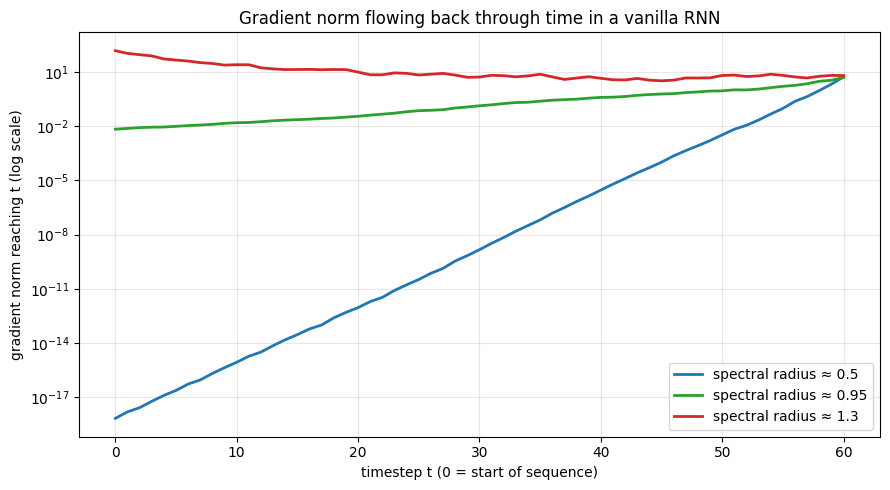

In [3]:
def grad_reaching_back(spectral_scale, Tlen=60, n_h=32):
    # RNN whose Whh is scaled to a target spectral radius; inject gradient only at the last step
    W = np.random.randn(n_h, n_h); W *= spectral_scale / np.abs(np.linalg.eigvals(W)).max()
    hs = [np.zeros(n_h)]
    xs = [np.random.randn(n_h)*0.1 for _ in range(Tlen)]
    for x in xs:
        hs.append(np.tanh(W @ hs[-1] + x))
    dh = np.random.randn(n_h)                 # gradient injected at final timestep
    norms = [np.linalg.norm(dh)]
    for t in reversed(range(Tlen)):
        dh = W.T @ ((1 - hs[t+1]**2) * dh)
        norms.append(np.linalg.norm(dh))
    return np.array(norms[::-1])

fig, ax = plt.subplots(figsize=(9, 5))
for scale, c in [(0.5, "tab:blue"), (0.95, "tab:green"), (1.3, "tab:red")]:
    ax.plot(grad_reaching_back(scale), lw=2, color=c, label=f"spectral radius ≈ {scale}")
ax.set_yscale("log")
ax.set_title("Gradient norm flowing back through time in a vanilla RNN")
ax.set_xlabel("timestep t (0 = start of sequence)"); ax.set_ylabel("gradient norm reaching t (log scale)")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()


**What to notice.** With $W_{hh}$'s spectral radius $<1$ (blue) the gradient reaching early timesteps is ~$10^{-8}$ — those timesteps get **no learning signal**, so the RNN is blind to long-range structure ("the *cat*, which … , *was* tired" — it forgets *cat* by the time it needs to agree *was*). With radius $>1$ (red) the gradient explodes. Only a razor-thin band near 1 (green) is stable, and you can't keep the weights there during training. **This is why vanilla RNNs fail on long sequences** — and the direct motivation for the LSTM.


## 3. The LSTM — a gated cell-state highway

The LSTM (Hochreiter & Schmidhuber, 1997) fixes vanishing gradients with an explicit **cell state** $c_t$ that is updated *additively* rather than multiplicatively, plus **gates** (learned sigmoid valves) that control information flow:
$$
\begin{aligned}
f_t &= \sigma(W_f[h_{t-1}, x_t]) &&\text{forget gate: what to erase from } c\\
i_t &= \sigma(W_i[h_{t-1}, x_t]) &&\text{input gate: how much new info to write}\\
g_t &= \tanh(W_g[h_{t-1}, x_t]) &&\text{candidate values to write}\\
o_t &= \sigma(W_o[h_{t-1}, x_t]) &&\text{output gate: what to expose as } h\\
c_t &= f_t \odot c_{t-1} + i_t \odot g_t &&\textbf{cell update (the highway)}\\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}
$$
**Why it fixes vanishing gradients:** the cell update $c_t = f_t\odot c_{t-1} + \dots$ has a nearly-**additive** path (when the forget gate $f_t\approx 1$). The gradient flows back through $c$ multiplied only by $f_t$ (≈1), *not* by a weight matrix raised to a power — so it can travel hundreds of steps without vanishing. It's the same "+1 highway" idea as residual connections (NB5), applied across time. Let's build an LSTM cell and verify it against PyTorch.


In [4]:
def sigmoid(x): return 1/(1+np.exp(-x))

class LSTMCell:
    def __init__(self, n_in, n_h):
        k = 1/np.sqrt(n_h); self.n_h = n_h
        # stacked weights for [i, f, g, o], input part and hidden part (torch layout)
        self.Wi = np.random.uniform(-k, k, (4*n_h, n_in))
        self.Wh = np.random.uniform(-k, k, (4*n_h, n_h))
        self.bi = np.zeros(4*n_h); self.bh = np.zeros(4*n_h)
    def step(self, x, h, c):
        z = self.Wi @ x + self.bi + self.Wh @ h + self.bh
        H = self.n_h
        i = sigmoid(z[0:H]); f = sigmoid(z[H:2*H]); g = np.tanh(z[2*H:3*H]); o = sigmoid(z[3*H:4*H])
        c = f * c + i * g
        h = o * np.tanh(c)
        return h, c

# verify one step vs torch.nn.LSTMCell (which uses the same i,f,g,o gate layout)
n_in, n_h = 4, 6
ours = LSTMCell(n_in, n_h)
tl = nn.LSTMCell(n_in, n_h).double()
with torch.no_grad():   # copy torch weights into ours
    ours.Wi = tl.weight_ih.numpy().copy(); ours.Wh = tl.weight_hh.numpy().copy()
    ours.bi = tl.bias_ih.numpy().copy();   ours.bh = tl.bias_hh.numpy().copy()
x = np.random.randn(n_in); h0 = np.random.randn(n_h); c0 = np.random.randn(n_h)
h_ours, c_ours = ours.step(x, h0, c0)
h_t, c_t = tl(torch.tensor(x)[None], (torch.tensor(h0)[None], torch.tensor(c0)[None]))
print("LSTM cell vs torch.nn.LSTMCell:")
print("    h max abs err =", np.abs(h_ours - h_t.detach().numpy()[0]).max())
print("    c max abs err =", np.abs(c_ours - c_t.detach().numpy()[0]).max())
assert np.abs(h_ours - h_t.detach().numpy()[0]).max() < 1e-12
print("✅ our LSTM cell matches PyTorch")


LSTM cell vs torch.nn.LSTMCell:
    h max abs err = 5.551115123125783e-17
    c max abs err = 1.1102230246251565e-16
✅ our LSTM cell matches PyTorch


**What to notice.** Our from-scratch LSTM cell matches `torch.nn.LSTMCell` to machine precision — the gate equations are exactly right. The conceptual payoff: the four gates let the network *learn* when to remember (forget gate near 1), when to overwrite (input gate), and when to read out (output gate). The additive cell highway is what makes those long-range memories survive backprop.


## 4. A character-level language model

The classic RNN demo (Karpathy's "Unreasonable Effectiveness"): train on raw text, predict the next character, then **generate** by sampling one character at a time and feeding it back. We train a PyTorch LSTM (for speed) on a small corpus and watch it learn spelling, spacing, and structure from nothing but characters.


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# a small self-contained corpus (repeat a paragraph so the model has something learnable)
text = ("the quick brown fox jumps over the lazy dog. "
        "deep learning models learn patterns from data. "
        "recurrent networks read sequences one step at a time. ") * 200
chars = sorted(set(text)); V = len(chars)
stoi = {c:i for i,c in enumerate(chars)}; itos = {i:c for c,i in stoi.items()}
data = np.array([stoi[c] for c in text])
print(f"corpus {len(text)} chars, vocab {V}: {''.join(chars)!r}")

class CharLSTM(nn.Module):
    def __init__(self, V, n_emb=32, n_h=128):
        super().__init__()
        self.emb = nn.Embedding(V, n_emb)
        self.lstm = nn.LSTM(n_emb, n_h, batch_first=True)
        self.head = nn.Linear(n_h, V)
    def forward(self, x, state=None):
        e = self.emb(x); out, state = self.lstm(e, state); return self.head(out), state

model = CharLSTM(V).to(device)
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
lossf = nn.CrossEntropyLoss()
seq_len, bs = 40, 64
def get_batch():
    ix = np.random.randint(0, len(data)-seq_len-1, bs)
    xb = np.stack([data[i:i+seq_len] for i in ix]); yb = np.stack([data[i+1:i+seq_len+1] for i in ix])
    return (torch.tensor(xb, device=device, dtype=torch.long),
            torch.tensor(yb, device=device, dtype=torch.long))

for step in range(600):
    xb, yb = get_batch()
    logits, _ = model(xb)
    loss = lossf(logits.reshape(-1, V), yb.reshape(-1))
    opt.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 5.0)     # gradient clipping (tames RNN explosions)
    opt.step()
    if step % 150 == 0 or step == 599: print(f"step {step:3d}  loss {loss.item():.3f}")


corpus 29200 chars, vocab 28: ' .abcdefghijklmnopqrstuvwxyz'


step   0  loss 3.321


step 150  loss 0.084


step 300  loss 0.065


step 450  loss 0.051


step 599  loss 0.046


In [6]:
@torch.no_grad()
def generate(model, prime="the ", n=200, temp=0.8):
    model.eval()
    idx = [stoi[c] for c in prime]; state = None
    x = torch.tensor(idx, device=device)[None]
    logits, state = model(x, state)
    out = list(prime)
    for _ in range(n):
        probs = torch.softmax(logits[0, -1] / temp, -1)
        nxt = torch.multinomial(probs, 1)
        out.append(itos[nxt.item()])
        logits, state = model(nxt[None], state)
    return "".join(out)

print("generated sample:\n")
print(generate(model, prime="the ", n=220))


generated sample:



the lazy dog. deep learning models learn patterns from data. recurrent networks read sequences one step at a time. the quick brown fox jumps over the lazy dog. deep learning models learn patterns from data. recurrent network


**What to notice.** From a random start (which would output gibberish like `qz7 fk;x`), after a few hundred steps the LSTM produces real words, correct spacing, and plausible sentence fragments in the style of the corpus — it learned the statistics of character sequences with **no dictionary, no grammar rules**, purely by predicting the next character. Two practical details you just used: **gradient clipping** (`clip_grad_norm_`) which caps the exploding-gradient half of the problem, and **temperature** sampling which trades off coherence vs diversity (we'll dig into decoding in NB13).

## 5. What you built / learned
- A vanilla **RNN** with hand-derived **BPTT**, verified against PyTorch.
- The **vanishing/exploding gradient** problem, measured: gradients decay as $W_{hh}^{T}$, killing long-range learning.
- An **LSTM** cell whose additive gated cell-state is a gradient highway across time (verified vs PyTorch).
- A **char-level language model** that generates text, using gradient clipping and temperature.

## 6. The bridge to transformers
RNNs process sequences **step by step**, so (a) they're inherently sequential (can't parallelize across time — slow to train), and (b) even LSTMs struggle past a few hundred tokens. **Attention** (next tier) throws out recurrence entirely: every position looks *directly* at every other position in one parallel operation — no long chain of matrix multiplies to vanish through. That's the leap that made GPT possible, and it's exactly what NB10 builds.

## 7. Exercises
1. **Long-dependency task.** Train an RNN vs LSTM to remember the first character of a sequence and output it at the end (the "copy task") at lengths 10, 50, 200. Where does the RNN break?
2. **BPTT truncation.** Implement truncated BPTT (backprop only $k$ steps). How does $k$ trade off memory vs long-range learning?
3. **GRU.** Implement a GRU cell (2 gates instead of 3) and compare to the LSTM on the char-LM.
4. **Temperature sweep.** Generate at temperature 0.2, 0.8, 1.5. Describe the coherence/diversity tradeoff.
5. **Exploding gradients.** Remove `clip_grad_norm_` and initialize with a large recurrent weight scale. Watch the loss NaN. Re-add clipping.
6. **Stacked / bidirectional.** Add a second LSTM layer, or make it bidirectional. When is bidirectional valid (and when is it cheating)?

## 8. Interview / residency framing
- *"Why do vanilla RNNs fail on long sequences?"* → gradient through time ≈ $W_{hh}^T$; eigenvalues <1 vanish, >1 explode; only a knife-edge is stable.
- *"How does an LSTM fix it?"* → additive cell-state update ($c_t=f_t c_{t-1}+i_t g_t$) gives a gradient highway (multiply by $f_t\approx1$, not a weight-matrix power); gates learn when to remember/overwrite/read.
- *"What is BPTT?"* → unroll the RNN over time into a feedforward graph, backprop through it; gradient at each step = local output grad + grad from the future.
- *"Gradient clipping — what and why?"* → rescale the gradient if its norm exceeds a threshold; prevents the exploding-gradient half of the RNN problem.
- *"Why did transformers replace RNNs?"* → recurrence is sequential (no parallelism across time) and still range-limited; attention connects all positions directly, in parallel.

---
**Next:** *Tier 1 · Notebook 9 — Regularization & training dynamics*: dropout, label smoothing, learning-rate schedules (warmup + cosine), gradient clipping, and early stopping — the practical knobs that make training actually work, each shown changing a real curve.


## 📚 References & papers

This notebook reproduces / builds on:

- **Long Short-Term Memory** — Hochreiter & Schmidhuber (1997), *Neural Computation*.
- **Backpropagation Through Time** — Werbos (1990), Proc. IEEE.
- **The Unreasonable Effectiveness of Recurrent Neural Networks** — Karpathy (2015). The char-RNN demo.
- **Learning Phrase Representations using RNN Encoder-Decoder (GRU)** — Cho et al. (2014), arXiv:1406.1078.